Otsu Optimal Threshold: 112.0


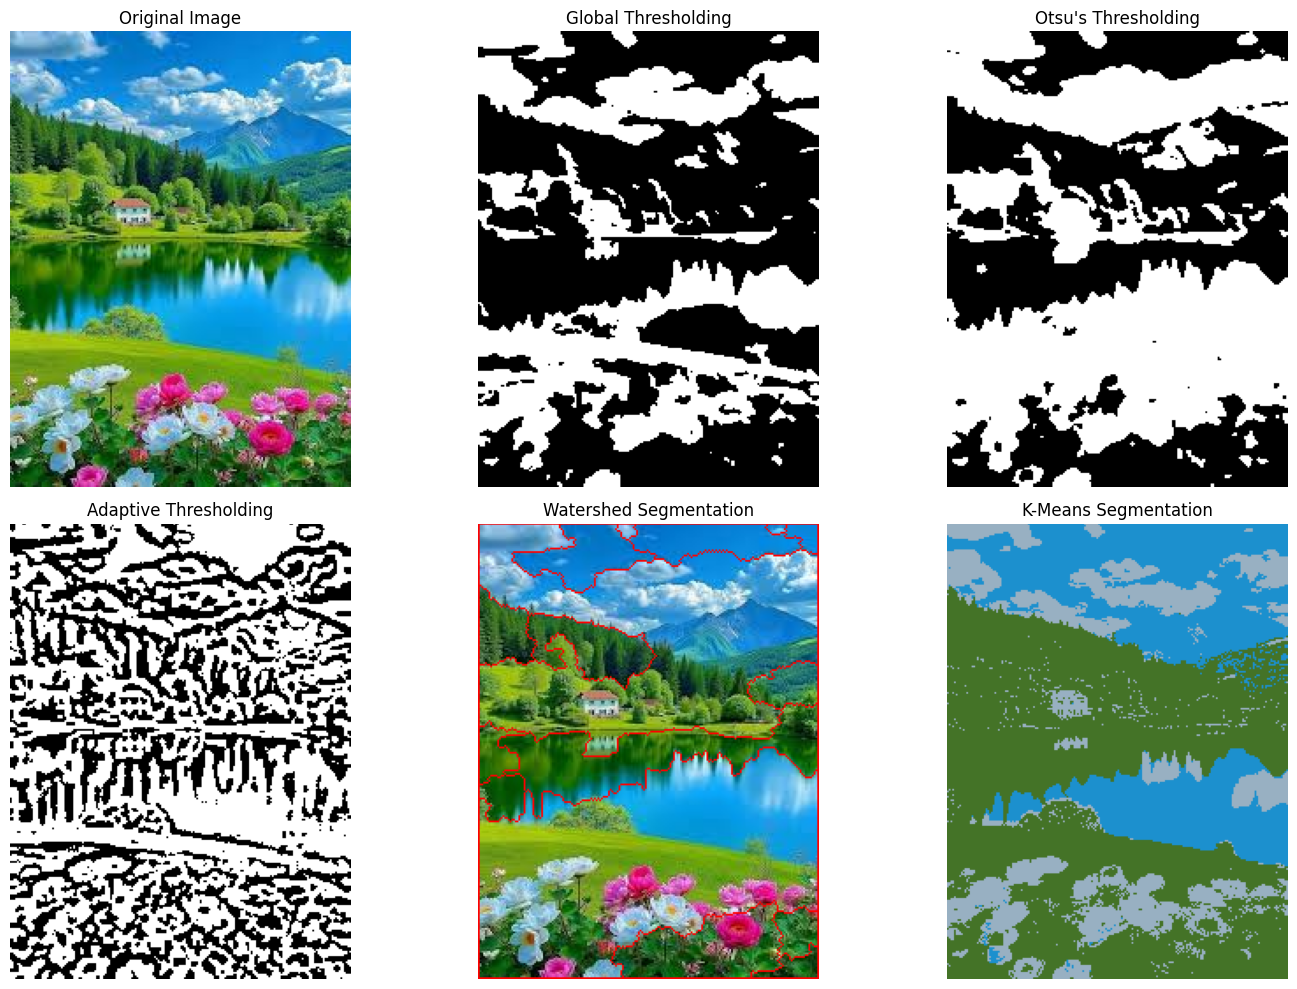

In [1]:
# 1. Import required libraries
import cv2
import numpy as np
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# Load a real-world image
image = cv2.imread("scenery.jpeg")

# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Gaussian Blur for noise reduction
blurred = cv2.GaussianBlur(gray, (5, 5), 0)


# 3. Global Thresholding

_, global_thresh = cv2.threshold(
    blurred, 127, 255, cv2.THRESH_BINARY
)

# 4. Otsu's Thresholding

otsu_threshold, otsu_thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Optimal Threshold:", otsu_threshold)

# 5. Adaptive Thresholding

adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# 6. Watershed Segmentation


# Binary image
_, binary = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise using morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN, kernel, iterations=2
)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1
markers[unknown == 255] = 0

# Apply Watershed
watershed_image = image.copy()
markers = cv2.watershed(watershed_image, markers)

# Mark boundaries in red
watershed_image[markers == -1] = [0, 0, 255]

watershed_rgb = cv2.cvtColor(
    watershed_image, cv2.COLOR_BGR2RGB
)

# 7. K-Means Clustering

# Reshape image into a list of pixels
pixels = image_rgb.reshape((-1, 3))
pixels = np.float32(pixels)

# Number of clusters
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)
centers = np.uint8(kmeans.cluster_centers_)

# Replace each pixel with its cluster center
segmented_pixels = centers[labels]

segmented_image = segmented_pixels.reshape(image_rgb.shape)

# 8. Display all segmentation results

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_rgb)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()